In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("imdb_top_1000.csv")
print(df.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [3]:
def sentiment(rating):

    if rating >= 8:
        return "Positive"

    elif rating >= 7:
        return "Neutral"

    else:
        return "Negative"

df["Sentiment"] = df["IMDB_Rating"].apply(sentiment)

In [4]:
print(df[['Series_Title',
          'IMDB_Rating',
          'Sentiment']].head())

               Series_Title  IMDB_Rating Sentiment
0  The Shawshank Redemption          9.3  Positive
1             The Godfather          9.2  Positive
2           The Dark Knight          9.0  Positive
3    The Godfather: Part II          9.0  Positive
4              12 Angry Men          9.0  Positive


In [5]:
counts = df["Sentiment"].value_counts()
print(counts)

Sentiment
Neutral     537
Positive    463
Name: count, dtype: int64


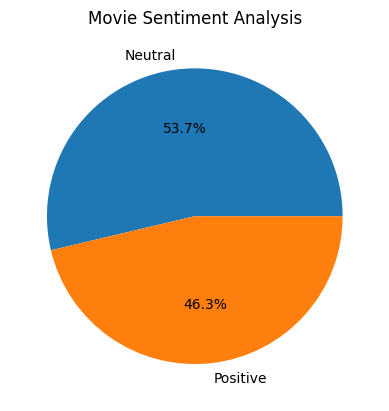

In [6]:
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%"
)
plt.title("Movie Sentiment Analysis")
plt.show()

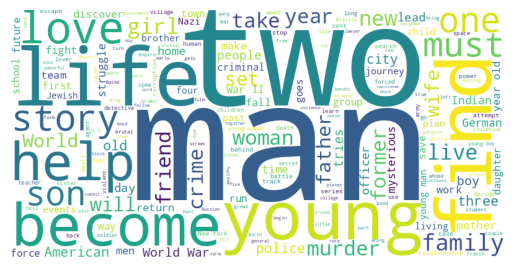

In [7]:
positive = " ".join(
df[df["Sentiment"]=="Positive"]
["Overview"]
.astype(str)
)
wc = WordCloud(
width=800,
height=400,
background_color='white'
).generate(positive)
plt.imshow(wc)
plt.axis("off")
plt.show()